In [3]:
%pip uninstall -y PIL Pillow

%pip install -q --no-cache-dir --force-reinstall "pillow==10.4.0"

%pip install -qU openai pymupdf pydantic reportlab pandas arabic-reshaper python-bidi

Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 75.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.0/472.0 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 25.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are ins

In [4]:
import PIL
print("Pillow version:", PIL.__version__)
print("Pillow path:", PIL.__file__)

from PIL import Image, ImageDraw, ImageFont

print("Pillow import works.")

Pillow version: 11.3.0
Pillow path: /usr/local/lib/python3.12/dist-packages/PIL/__init__.py
Pillow import works.


In [5]:
import os
import re
import json
import base64
import mimetypes
import getpass
from pathlib import Path
from typing import Optional, List

import fitz  # PyMuPDF
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from pydantic import BaseModel, Field
from openai import OpenAI

In [6]:
INPUT_DIR = Path("vlm_inputs")
OUTPUT_DIR = Path("vlm_outputs")
AR_DIR = Path("data/HR/applications/ar")

INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AR_DIR.mkdir(parents=True, exist_ok=True)

print("Input folder:", INPUT_DIR.resolve())
print("Output folder:", OUTPUT_DIR.resolve())
print("Arabic PDF folder:", AR_DIR.resolve())

Input folder: /content/vlm_inputs
Output folder: /content/vlm_outputs
Arabic PDF folder: /content/data/HR/applications/ar


In [7]:

api_key = getpass.getpass("Paste your OpenRouter API key: ").strip()
os.environ["OPENROUTER_API_KEY"] = api_key

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

print("Key loaded:", bool(os.environ["OPENROUTER_API_KEY"]))

Paste your OpenRouter API key: ··········
Key loaded: True


In [8]:
VISION_MODEL = "openrouter/free"

def image_to_data_url(image_path):
    image_path = Path(image_path)
    mime_type, _ = mimetypes.guess_type(image_path)

    if mime_type is None:
        mime_type = "image/png"

    image_bytes = image_path.read_bytes()
    encoded = base64.b64encode(image_bytes).decode("utf-8")

    return f"data:{mime_type};base64,{encoded}"


def ask_vlm(image_paths, prompt, model=VISION_MODEL, max_tokens=1200):
    content = [{"type": "text", "text": prompt}]

    for image_path in image_paths:
        content.append({
            "type": "image_url",
            "image_url": {
                "url": image_to_data_url(image_path)
            }
        })

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": content
            }
        ],
        temperature=0,
        max_tokens=max_tokens,
    )

    return response.choices[0].message.content


def extract_json(text):
    text = text.strip()
    text = text.replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(text)
    except:
        pass

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        return json.loads(match.group(0))

    raise ValueError("No valid JSON found:\n" + text)


def save_json(data, path):
    path = Path(path)
    path.write_text(
        json.dumps(data, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )
    print("Saved:", path)

In [9]:
from pathlib import Path

INPUT_DIR = Path("vlm_inputs")
OUTPUT_DIR = Path("vlm_outputs")
AR_DIR = Path("data/HR/applications/ar")

INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AR_DIR.mkdir(parents=True, exist_ok=True)

print("Input folder:", INPUT_DIR.resolve())
print("Output folder:", OUTPUT_DIR.resolve())
print("Arabic PDF folder:", AR_DIR.resolve())

Input folder: /content/vlm_inputs
Output folder: /content/vlm_outputs
Arabic PDF folder: /content/data/HR/applications/ar


In [10]:
from PIL import Image, ImageDraw, ImageFont

Created: vlm_inputs/receipt.png


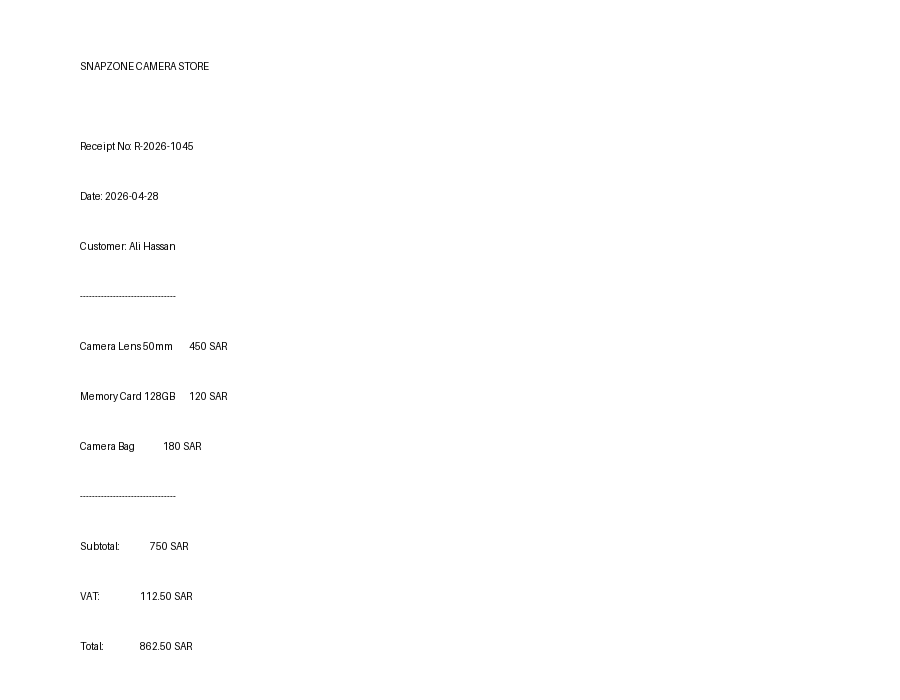

In [11]:
receipt_path = INPUT_DIR / "receipt.png"

img = Image.new("RGB", (900, 700), "white")
draw = ImageDraw.Draw(img)

try:
    font_title = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 42)
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 30)
except:
    font_title = None
    font = None

lines = [
    ("SNAPZONE CAMERA STORE", 80, 60, font_title),
    ("Receipt No: R-2026-1045", 80, 140, font),
    ("Date: 2026-04-28", 80, 190, font),
    ("Customer: Ali Hassan", 80, 240, font),
    ("--------------------------------", 80, 290, font),
    ("Camera Lens 50mm        450 SAR", 80, 340, font),
    ("Memory Card 128GB       120 SAR", 80, 390, font),
    ("Camera Bag              180 SAR", 80, 440, font),
    ("--------------------------------", 80, 490, font),
    ("Subtotal:               750 SAR", 80, 540, font),
    ("VAT:                    112.50 SAR", 80, 590, font),
    ("Total:                  862.50 SAR", 80, 640, font),
]

for text, x, y, f in lines:
    draw.text((x, y), text, fill="black", font=f)

img.save(receipt_path)

print("Created:", receipt_path)
display(img)

In [12]:
from typing import Optional, List
from pydantic import BaseModel, Field

In [13]:
class ReceiptItem(BaseModel):
    item_name: Optional[str] = None
    price: Optional[float] = None


class ReceiptInfo(BaseModel):
    store_name: Optional[str] = None
    receipt_no: Optional[str] = None
    date: Optional[str] = None
    customer: Optional[str] = None
    subtotal: Optional[float] = None
    vat: Optional[float] = None
    total: Optional[float] = None
    currency: Optional[str] = None
    items: List[ReceiptItem] = Field(default_factory=list)

In [14]:
receipt_prompt = """
Extract structured information from this receipt image.

Return JSON only. Do not explain anything.

Use exactly this structure:
{
  "store_name": null,
  "receipt_no": null,
  "date": null,
  "customer": null,
  "subtotal": null,
  "vat": null,
  "total": null,
  "currency": null,
  "items": [
    {
      "item_name": null,
      "price": null
    }
  ]
}
"""

receipt_raw = ask_vlm([receipt_path], receipt_prompt)

print("RAW RESPONSE:")
print(receipt_raw)

RAW RESPONSE:
{
  "store_name": "SNAPZONE CAMERA STORE",
  "receipt_no": "R-2026-1045",
  "date": "2026-04-28",
  "customer": "Ali Hassan",
  "subtotal": 750,
  "vat": 112.50,
  "total": 862.50,
  "currency": "SAR",
  "items": [
    {
      "item_name": "Camera Lens 50mm",
      "price": 450
    },
    {
      "item_name": "Memory Card 128GB",
      "price": 120
    },
    {
      "item_name": "Camera Bag",
      "price": 180
    }
  ]
}


In [15]:
receipt_data = extract_json(receipt_raw)
receipt_result = ReceiptInfo.model_validate(receipt_data)

receipt_result

ReceiptInfo(store_name='SNAPZONE CAMERA STORE', receipt_no='R-2026-1045', date='2026-04-28', customer='Ali Hassan', subtotal=750.0, vat=112.5, total=862.5, currency='SAR', items=[ReceiptItem(item_name='Camera Lens 50mm', price=450.0), ReceiptItem(item_name='Memory Card 128GB', price=120.0), ReceiptItem(item_name='Camera Bag', price=180.0)])

In [16]:
save_json(receipt_result.model_dump(), OUTPUT_DIR / "task1_receipt_extraction.json")

print("Store:", receipt_result.store_name)
print("Receipt No:", receipt_result.receipt_no)
print("Date:", receipt_result.date)
print("Total:", receipt_result.total, receipt_result.currency)
print("Items:", receipt_result.items)

Saved: vlm_outputs/task1_receipt_extraction.json
Store: SNAPZONE CAMERA STORE
Receipt No: R-2026-1045
Date: 2026-04-28
Total: 862.5 SAR
Items: [ReceiptItem(item_name='Camera Lens 50mm', price=450.0), ReceiptItem(item_name='Memory Card 128GB', price=120.0), ReceiptItem(item_name='Camera Bag', price=180.0)]


Created image: vlm_inputs/resume_page.png
Created PDF: vlm_inputs/resume.pdf


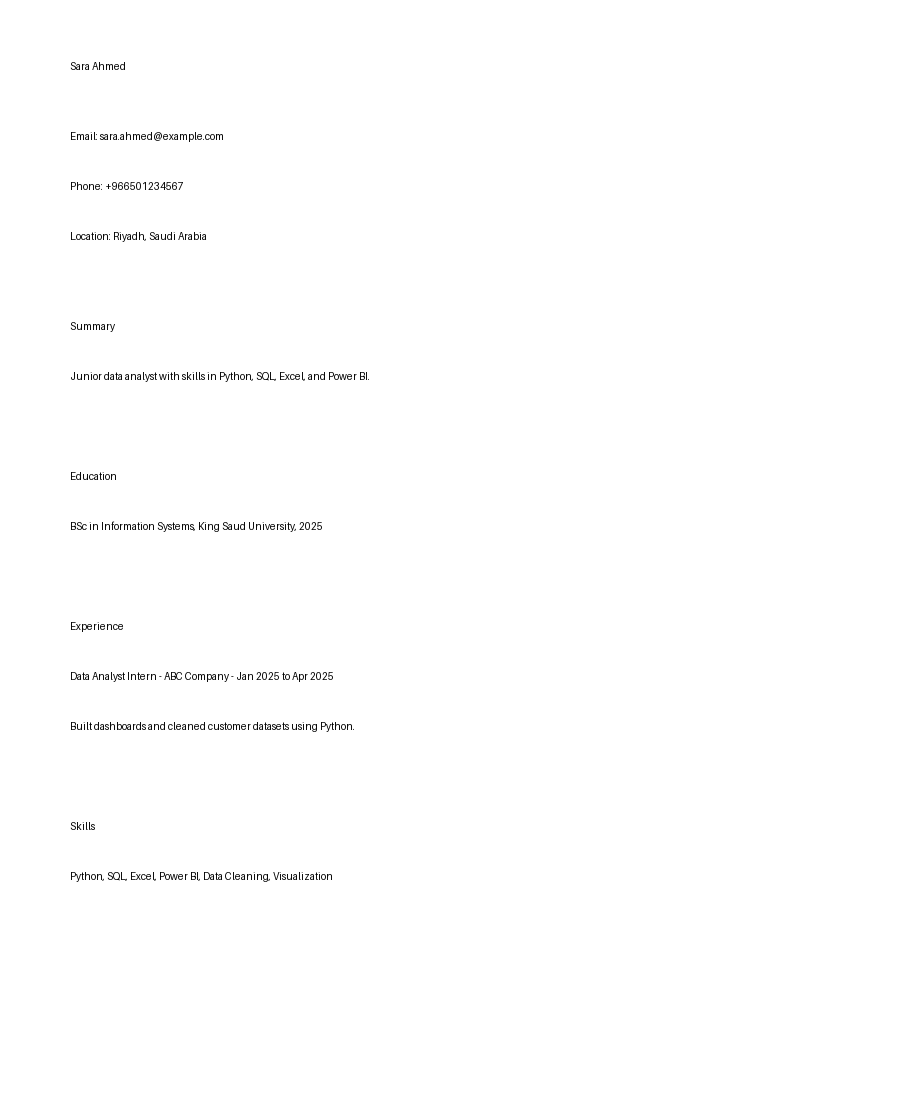

In [18]:
from reportlab.pdfgen import canvas

resume_image_path = INPUT_DIR / "resume_page.png"
resume_pdf_path = INPUT_DIR / "resume.pdf"

img_width = 900
img_height = 1100

img = Image.new("RGB", (img_width, img_height), "white")
draw = ImageDraw.Draw(img)

try:
    font_title = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 44)
    font_heading = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 32)
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 27)
except:
    font_title = None
    font_heading = None
    font = None

lines = [
    ("Sara Ahmed", 70, 60, font_title),
    ("Email: sara.ahmed@example.com", 70, 130, font),
    ("Phone: +966501234567", 70, 180, font),
    ("Location: Riyadh, Saudi Arabia", 70, 230, font),

    ("Summary", 70, 320, font_heading),
    ("Junior data analyst with skills in Python, SQL, Excel, and Power BI.", 70, 370, font),

    ("Education", 70, 470, font_heading),
    ("BSc in Information Systems, King Saud University, 2025", 70, 520, font),

    ("Experience", 70, 620, font_heading),
    ("Data Analyst Intern - ABC Company - Jan 2025 to Apr 2025", 70, 670, font),
    ("Built dashboards and cleaned customer datasets using Python.", 70, 720, font),

    ("Skills", 70, 820, font_heading),
    ("Python, SQL, Excel, Power BI, Data Cleaning, Visualization", 70, 870, font),
]

for text, x, y, f in lines:
    draw.text((x, y), text, fill="black", font=f)

# Save image
img.save(resume_image_path)

# Create PDF using reportlab instead of Pillow PDF save
pdf = canvas.Canvas(str(resume_pdf_path), pagesize=(img_width, img_height))
pdf.drawImage(str(resume_image_path), 0, 0, width=img_width, height=img_height)
pdf.save()

print("Created image:", resume_image_path)
print("Created PDF:", resume_pdf_path)

display(img)

In [19]:
def pdf_to_images(pdf_path, output_folder, max_pages=2, zoom=2):
    pdf_path = Path(pdf_path)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    doc = fitz.open(pdf_path)
    image_paths = []

    for page_index in range(min(len(doc), max_pages)):
        page = doc[page_index]
        matrix = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=matrix, alpha=False)

        out_path = output_folder / f"{pdf_path.stem}_page_{page_index + 1}.png"
        pix.save(out_path)
        image_paths.append(out_path)

    return image_paths


resume_page_images = pdf_to_images(
    resume_pdf_path,
    OUTPUT_DIR / "resume_pages",
    max_pages=1
)

resume_page_images

[PosixPath('vlm_outputs/resume_pages/resume_page_1.png')]

In [20]:
class ExperienceItem(BaseModel):
    title: Optional[str] = None
    company: Optional[str] = None
    dates: Optional[str] = None
    description: Optional[str] = None


class ResumeInfo(BaseModel):
    candidate_name: Optional[str] = None
    email: Optional[str] = None
    phone: Optional[str] = None
    location: Optional[str] = None
    summary: Optional[str] = None
    education: List[str] = Field(default_factory=list)
    skills: List[str] = Field(default_factory=list)
    experience: List[ExperienceItem] = Field(default_factory=list)

In [21]:
resume_prompt = """
Extract structured information from this resume image.

Return JSON only. Do not explain anything.

Use exactly this structure:
{
  "candidate_name": null,
  "email": null,
  "phone": null,
  "location": null,
  "summary": null,
  "education": [],
  "skills": [],
  "experience": [
    {
      "title": null,
      "company": null,
      "dates": null,
      "description": null
    }
  ]
}
"""

resume_raw = ask_vlm(resume_page_images, resume_prompt)

print("RAW RESPONSE:")
print(resume_raw)

RAW RESPONSE:
```json
{
  "candidate_name": "Sara Ahmed",
  "email": "sara.ahmed@example.com",
  "phone": "+966501234567",
  "location": "Riyadh, Saudi Arabia",
  "summary": "Junior data analyst with skills in Python, SQL, Excel, and Power BI.",
  "education": [
    {
      "degree": "BSc in Information Systems",
      "institution": "King Saud University",
      "graduation_year": "2025"
    }
  ],
  "skills": [
    "Python",
    "SQL",
    "Excel",
    "Power BI",
    "Data Cleaning",
    "Visualization"
  ],
  "experience": [
    {
      "title": "Data Analyst Intern",
      "company": "ABC Company",
      "dates": "Jan 2025 to Apr 2025",
      "description": "Built dashboards and cleaned customer datasets using Python."
    }
  ]
}
```


In [22]:
resume_data = extract_json(resume_raw)

resume_data.setdefault("education", [])
resume_data.setdefault("skills", [])
resume_data.setdefault("experience", [])

# Fix education
fixed_education = []

if isinstance(resume_data["education"], str):
    fixed_education = [resume_data["education"]]

elif isinstance(resume_data["education"], dict):
    edu_text = ", ".join(
        str(value) for value in resume_data["education"].values()
        if value is not None
    )
    fixed_education = [edu_text]

elif isinstance(resume_data["education"], list):
    for item in resume_data["education"]:
        if isinstance(item, str):
            fixed_education.append(item)
        elif isinstance(item, dict):
            edu_text = ", ".join(
                str(value) for value in item.values()
                if value is not None
            )
            fixed_education.append(edu_text)

resume_data["education"] = fixed_education

# Fix skills
if isinstance(resume_data["skills"], str):
    resume_data["skills"] = [
        skill.strip()
        for skill in resume_data["skills"].split(",")
    ]

# Fix experience
fixed_experience = []

for item in resume_data["experience"]:
    if isinstance(item, dict):
        fixed_experience.append({
            "title": item.get("title"),
            "company": item.get("company"),
            "dates": item.get("dates"),
            "description": item.get("description"),
        })
    elif isinstance(item, str):
        fixed_experience.append({
            "title": None,
            "company": None,
            "dates": None,
            "description": item
        })

resume_data["experience"] = fixed_experience

resume_result = ResumeInfo.model_validate(resume_data)

resume_result

ResumeInfo(candidate_name='Sara Ahmed', email='sara.ahmed@example.com', phone='+966501234567', location='Riyadh, Saudi Arabia', summary='Junior data analyst with skills in Python, SQL, Excel, and Power BI.', education=['BSc in Information Systems, King Saud University, 2025'], skills=['Python', 'SQL', 'Excel', 'Power BI', 'Data Cleaning', 'Visualization'], experience=[ExperienceItem(title='Data Analyst Intern', company='ABC Company', dates='Jan 2025 to Apr 2025', description='Built dashboards and cleaned customer datasets using Python.')])

In [23]:
save_json(resume_result.model_dump(), OUTPUT_DIR / "task1_resume_extraction.json")

print("Name:", resume_result.candidate_name)
print("Email:", resume_result.email)
print("Phone:", resume_result.phone)
print("Skills:", resume_result.skills)
print("Experience:", resume_result.experience)

Saved: vlm_outputs/task1_resume_extraction.json
Name: Sara Ahmed
Email: sara.ahmed@example.com
Phone: +966501234567
Skills: ['Python', 'SQL', 'Excel', 'Power BI', 'Data Cleaning', 'Visualization']
Experience: [ExperienceItem(title='Data Analyst Intern', company='ABC Company', dates='Jan 2025 to Apr 2025', description='Built dashboards and cleaned customer datasets using Python.')]


In [24]:
%pip install -qU "transformers>=4.46.0" qwen_vl_utils accelerate peft bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 24.5 MB/s eta 0:00:00


In [25]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU found. QARI may be slow or fail on CPU.")

CUDA available: True
GPU: Tesla T4


Created image: data/HR/applications/ar/my_resume_page.png
Created PDF: data/HR/applications/ar/my_resume.pdf


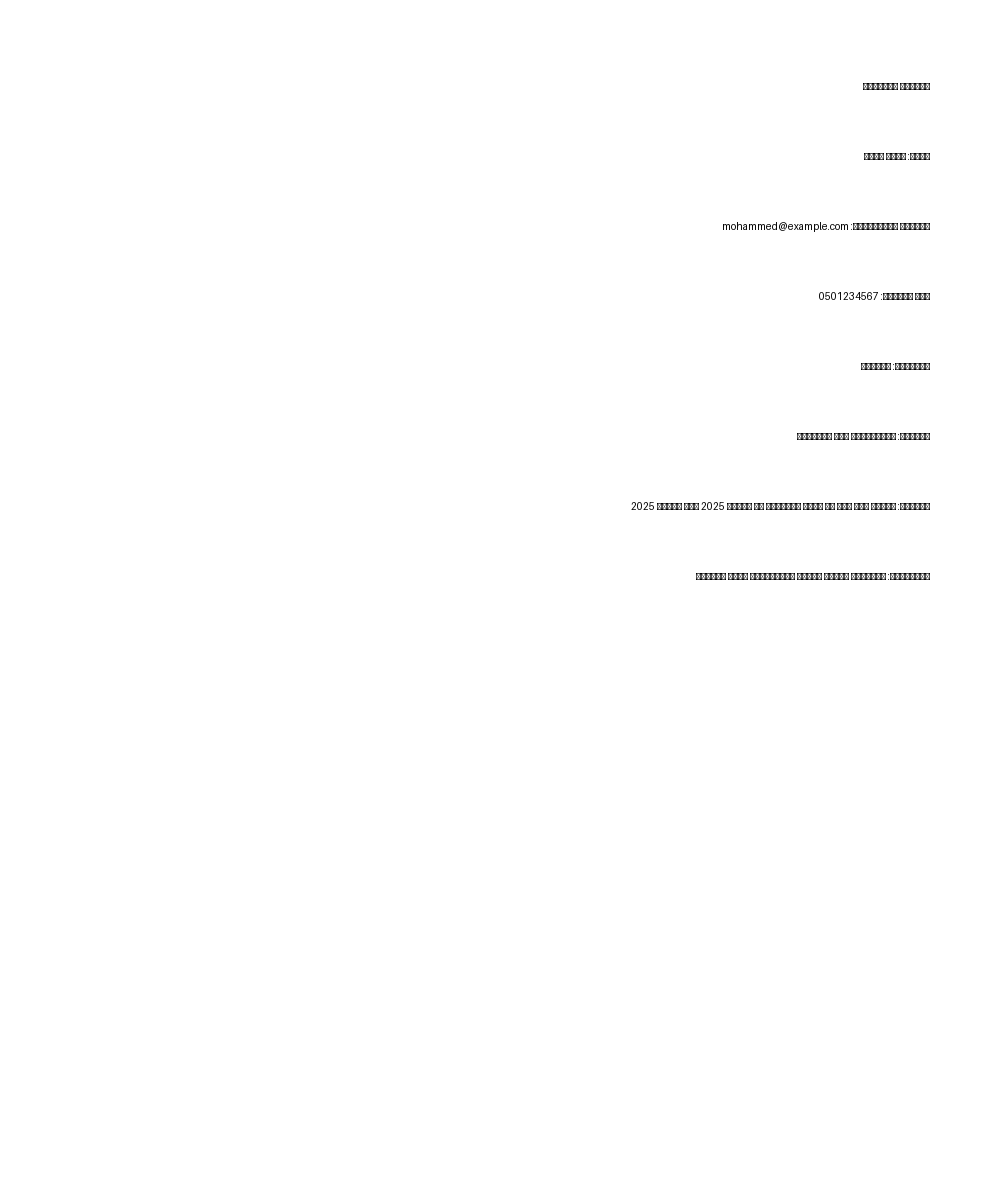

In [27]:
import arabic_reshaper
from bidi.algorithm import get_display
from reportlab.pdfgen import canvas
from PIL import Image, ImageDraw, ImageFont

def ar_text(text):
    return get_display(arabic_reshaper.reshape(text))


def create_arabic_document_image(lines, image_path, pdf_path=None):
    image_path = Path(image_path)
    image_path.parent.mkdir(parents=True, exist_ok=True)

    img_width = 1000
    img_height = 1200

    img = Image.new("RGB", (img_width, img_height), "white")
    draw = ImageDraw.Draw(img)

    try:
        font_title = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            42
        )
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            32
        )
    except:
        font_title = None
        font = None

    y = 80

    for i, line in enumerate(lines):
        current_font = font_title if i == 0 else font
        reshaped = ar_text(line)

        bbox = draw.textbbox((0, 0), reshaped, font=current_font)
        text_width = bbox[2] - bbox[0]
        x = 930 - text_width

        draw.text((x, y), reshaped, fill="black", font=current_font)
        y += 70

    # مهم: نحفظ PNG بدل JPG لتجنب خطأ Pillow
    img.save(image_path, format="PNG")

    # إنشاء PDF باستخدام reportlab بدل Pillow
    if pdf_path:
        pdf_path = Path(pdf_path)
        pdf_path.parent.mkdir(parents=True, exist_ok=True)

        pdf = canvas.Canvas(str(pdf_path), pagesize=(img_width, img_height))
        pdf.drawImage(
            str(image_path),
            0,
            0,
            width=img_width,
            height=img_height
        )
        pdf.save()

    return image_path


arabic_resume_img = AR_DIR / "my_resume_page.png"
arabic_resume_pdf = AR_DIR / "my_resume.pdf"

arabic_lines = [
    "السيرة الذاتية",
    "الاسم: محمد عبدالله",
    "البريد الإلكتروني: mohammed@example.com",
    "رقم الجوال: 0501234567",
    "المدينة: الرياض",
    "المؤهل: بكالوريوس نظم معلومات",
    "الخبرة: متدرب دعم فني في شركة التقنية من يونيو 2025 إلى أغسطس 2025",
    "المهارات: بايثون، إكسل، تحليل البيانات، خدمة العملاء"
]

create_arabic_document_image(
    arabic_lines,
    arabic_resume_img,
    arabic_resume_pdf
)

print("Created image:", arabic_resume_img)
print("Created PDF:", arabic_resume_pdf)

display(Image.open(arabic_resume_img))

In [28]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

QARI_MODEL_NAME = "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct"

qari_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QARI_MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

qari_processor = AutoProcessor.from_pretrained(QARI_MODEL_NAME)

print("QARI model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

QARI model loaded.


In [29]:
def qari_ocr_image(image_path, max_tokens=2000):
    image_path = Path(image_path).resolve()

    prompt = """
Below is the image of one page of an Arabic document.
Return the text representation of this document naturally.
Preserve structure as much as possible.
Do not hallucinate.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": f"file://{image_path}"},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = qari_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = qari_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    if torch.cuda.is_available():
        inputs = inputs.to("cuda")

    with torch.no_grad():
        generated_ids = qari_model.generate(
            **inputs,
            max_new_tokens=max_tokens
        )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = qari_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text

In [30]:
arabic_pdf_files = list(AR_DIR.glob("*.pdf"))

print("Arabic PDF files:")
for file in arabic_pdf_files:
    print("-", file)

arabic_page_images = []

for pdf_file in arabic_pdf_files:
    pages = pdf_to_images(
        pdf_file,
        OUTPUT_DIR / "arabic_pages",
        max_pages=3,
        zoom=2
    )
    arabic_page_images.extend(pages)

print("\nRendered pages:")
for img_path in arabic_page_images:
    print("-", img_path)

Arabic PDF files:
- data/HR/applications/ar/my_resume.pdf

Rendered pages:
- vlm_outputs/arabic_pages/my_resume_page_1.png


In [31]:
arabic_ocr_results = []

for image_path in arabic_page_images:
    print("Processing:", image_path)

    text = qari_ocr_image(image_path)

    arabic_ocr_results.append({
        "image_path": str(image_path),
        "ocr_text": text
    })

    print(text)
    print("-" * 80)

save_json(arabic_ocr_results, OUTPUT_DIR / "task2_arabic_ocr_results.json")

Processing: vlm_outputs/arabic_pages/my_resume_page_1.png
<p><u>....</u> <u>....</u> <u>....</u> <u>....</u> <u>....</u></p><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><

In [32]:
def extract_arabic_resume_info(text):
    def find(pattern):
        match = re.search(pattern, text)
        return match.group(1).strip() if match else None

    info = {
        "name": find(r"الاسم[:：]\s*([^\n]+)"),
        "email": find(r"البريد الإلكتروني[:：]\s*([^\n]+)"),
        "phone": find(r"(?:رقم الجوال|الجوال|الهاتف)[:：]\s*([^\n]+)"),
        "city": find(r"المدينة[:：]\s*([^\n]+)"),
        "education": find(r"المؤهل[:：]\s*([^\n]+)"),
        "experience": find(r"الخبرة[:：]\s*([^\n]+)"),
        "skills": find(r"المهارات[:：]\s*([^\n]+)"),
        "raw_text": text
    }

    if info["skills"]:
        info["skills"] = [
            skill.strip()
            for skill in re.split(r"،|,", info["skills"])
        ]

    return info


arabic_structured_results = []

for item in arabic_ocr_results:
    extracted = extract_arabic_resume_info(item["ocr_text"])
    extracted["image_path"] = item["image_path"]
    arabic_structured_results.append(extracted)

arabic_structured_results

[{'name': None,
  'email': None,
  'phone': None,
  'city': None,
  'education': None,
  'experience': None,
  'skills': None,
  'raw_text': '<p><u>....</u> <u>....</u> <u>....</u> <u>....</u> <u>....</u></p><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4><br><h4></h4

In [33]:
save_json(
    arabic_structured_results,
    OUTPUT_DIR / "task2_arabic_structured_extraction.json"
)

df = pd.DataFrame(arabic_structured_results)

csv_path = OUTPUT_DIR / "task2_arabic_structured_extraction.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved CSV:", csv_path)
df

Saved: vlm_outputs/task2_arabic_structured_extraction.json
Saved CSV: vlm_outputs/task2_arabic_structured_extraction.csv


,name,email,phone,city,education,experience,skills,raw_text,image_path
0,None,None,None,None,None,None,None,<p><u>....</u> <u>....</u> <u>....</u> <u>.......,vlm_outputs/arabic_pages/my_resume_page_1.png


In [34]:
print("M2.Ex2 completed.")

print("\nGenerated files:")

for path in OUTPUT_DIR.rglob("*"):
    if path.is_file():
        print("-", path)

M2.Ex2 completed.

Generated files:
- vlm_outputs/task2_arabic_structured_extraction.json
- vlm_outputs/task2_arabic_ocr_results.json
- vlm_outputs/task2_arabic_structured_extraction.csv
- vlm_outputs/task1_receipt_extraction.json
- vlm_outputs/task1_resume_extraction.json
- vlm_outputs/arabic_pages/my_resume_page_1.png
- vlm_outputs/resume_pages/resume_page_1.png
